<a href="https://colab.research.google.com/github/ignaciovgl/ignaciovgl/blob/main/VAR/CVAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Portfolio Risk Analytics with VaR and CVaR

This notebook will guide you through building a portfolio risk assessment tool that calculates Value at Risk (VaR) and Conditional Value at Risk (CVaR) for a diversified asset portfolio.

### Step 1: Data Acquisition

To begin, we need to acquire historical price data for the assets in our portfolio. We'll use the `yfinance` library to download data from Yahoo Finance.

In [1]:
# Install yfinance if you haven't already
!pip install yfinance pandas numpy scipy PyPortfolioOpt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 5.0 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Define the portfolio assets (example: tech stocks, consumer goods, finance, energy)
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JNJ', 'PG', 'V', 'JPM', 'XOM', 'CVX']

# Define the date range for historical data
start_date = '2020-01-01'
end_date = '2023-12-31'

# Download historical adjusted close prices
# yf.download() now defaults to auto_adjust=True, returning only adjusted close prices
data = yf.download(tickers, start=start_date, end=end_date)

# Display the first few rows of the data
print("Historical Adjusted Close Prices:")
display(data.head())

# Calculate daily returns
returns = data.pct_change().dropna()
print("\nDaily Returns:")
display(returns.head())

/tmp/ipykernel_1709/1779324941.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  10 of 10 completed

Historical Adjusted Close Prices:


Price           Close                                               \
Ticker           AAPL       AMZN        CVX      GOOGL         JNJ   
Date                                                                 
2020-01-02  72.333885  94.900497  91.182579  67.832512  121.936966   
2020-01-03  71.630661  93.748497  90.867188  67.477669  120.525200   
2020-01-06  72.201416  95.143997  90.559311  69.276215  120.374832   
2020-01-07  71.861847  95.343002  89.402908  69.142403  121.109962   
2020-01-08  73.017830  94.598503  88.381676  69.634529  121.093262   

Price                                                                  ...  \
Ticker             JPM        MSFT          PG           V        XOM  ...   
Date                                                                   ...   
2020-01-02  118.430313  151.829544  104.735367  182.431061  52.947041  ...   
2020-01-03  116.867493  149.938995  104.030968  180.980133  52.521366  ...   
2020-01-06  116.774536  150.326569  104.175209  180.588837  52.924637  ...   
2020-01-07  114.789337  148.955948  103.530235  180.111557  52.491505  ...   
2020-01-08  115.684807  151.328537  103.971535  183.194733  51.699898  ...   

Price          Volume                                                  \
Ticker           AAPL      AMZN      CVX     GOOGL      JNJ       JPM   
Date                                                                    
2020-01-02  135480400  80580000  5205000  27278000  5777000  10803700   
2020-01-03  146322800  75288000  6360900  23408000  5752400  10386800   
2020-01-06  118387200  81236000  9953000  46768000  7731300  10259000   
2020-01-07  108872000  80898000  7856900  34330000  7382900  10531300   
2020-01-08  132079200  70160000  7295900  35314000  6605800   9695300   

Price                                              
Ticker          MSFT       PG         V       XOM  
Date                                               
2020-01-02  22622100  8130800   8733000  12456400  
2020-01-03  21116200  7970500   4899700  17386900  
2020-01-06  20813700  6674400  10109500  20081900  
2020-01-07  21634100  7583400   4392300  17387700  
2020-01-08  27746500  5385100   5712000  15137700  

[5 rows x 50 columns]


Daily Returns:


Price          Close                                                    \
Ticker          AAPL      AMZN       CVX     GOOGL       JNJ       JPM   
Date                                                                     
2020-01-03 -0.009722 -0.012139 -0.003459 -0.005231 -0.011578 -0.013196   
2020-01-06  0.007968  0.014886 -0.003388  0.026654 -0.001248 -0.000795   
2020-01-07 -0.004703  0.002092 -0.012770 -0.001932  0.006107 -0.017000   
2020-01-08  0.016086 -0.007809 -0.011423  0.007118 -0.000138  0.007801   
2020-01-09  0.021241  0.004799 -0.001614  0.010498  0.002966  0.003651   

Price                                               ...    Volume            \
Ticker          MSFT        PG         V       XOM  ...      AAPL      AMZN   
Date                                                ...                       
2020-01-03 -0.012452 -0.006726 -0.007953 -0.008040  ...  0.080029 -0.065674   
2020-01-06  0.002585  0.001387 -0.002162  0.007678  ... -0.190918  0.079003   
2020-01-07 -0.009118 -0.006191 -0.002643 -0.008184  ... -0.080374 -0.004161   
2020-01-08  0.015928  0.004263  0.017118 -0.015081  ...  0.213160 -0.132735   
2020-01-09  0.012493  0.010938  0.006930  0.007656  ...  0.287927 -0.097121   

Price                                                                   \
Ticker           CVX     GOOGL       JNJ       JPM      MSFT        PG   
Date                                                                     
2020-01-03  0.222075 -0.141873 -0.004258 -0.038589 -0.066568 -0.019715   
2020-01-06  0.564716  0.997949  0.344013 -0.012304 -0.014325 -0.162612   
2020-01-07 -0.210600 -0.265951 -0.045064  0.026543  0.039416  0.136192   
2020-01-08 -0.071402  0.028663 -0.105257 -0.079382  0.282535 -0.289883   
2020-01-09  0.006771 -0.059863 -0.074647 -0.023341 -0.229272  0.103786   

Price                           
Ticker             V       XOM  
Date                            
2020-01-03 -0.438944  0.395821  
2020-01-06  1.063290  0.155002  
2020-01-07 -0.565527 -0.134161  
2020-01-08  0.300458 -0.129402  
2020-01-09  0.181373 -0.021529  

[5 rows x 50 columns]

### Step 2: Exploratory Data Analysis (EDA) and Visualization

Before proceeding with risk calculations, let's visualize the historical adjusted close prices and daily returns to understand their behavior.

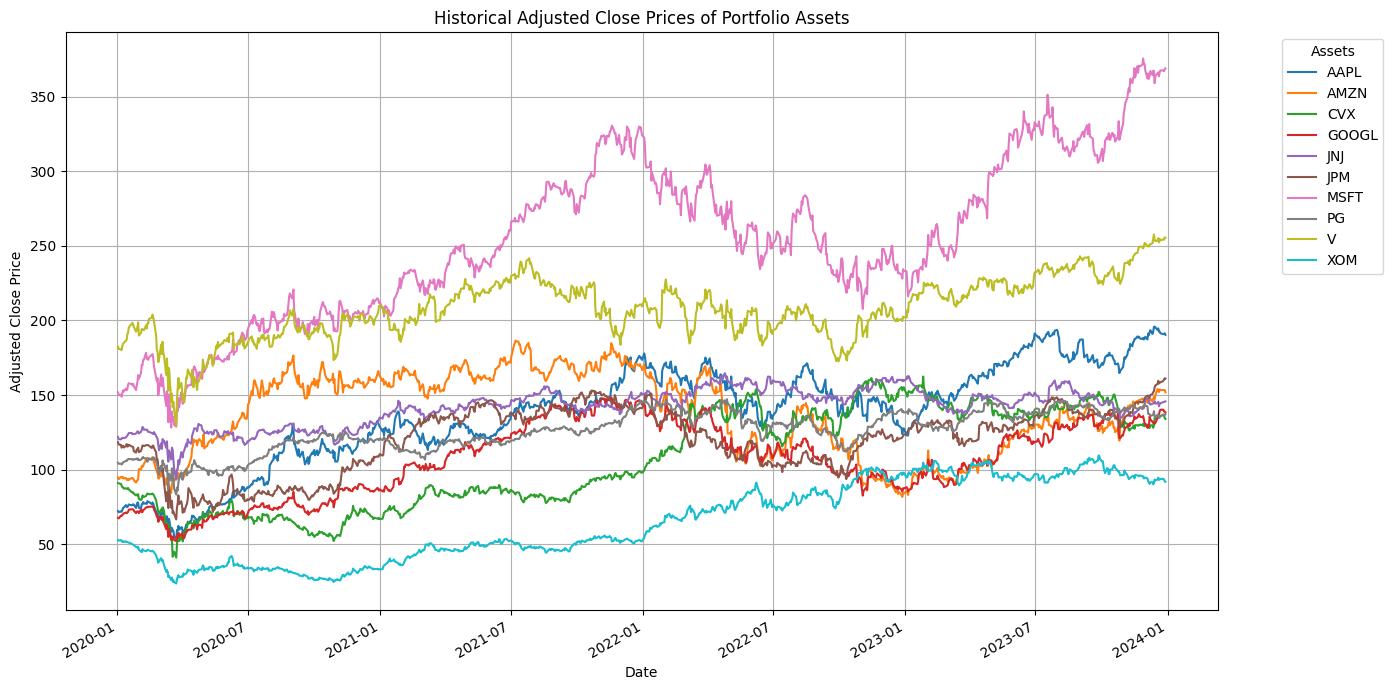

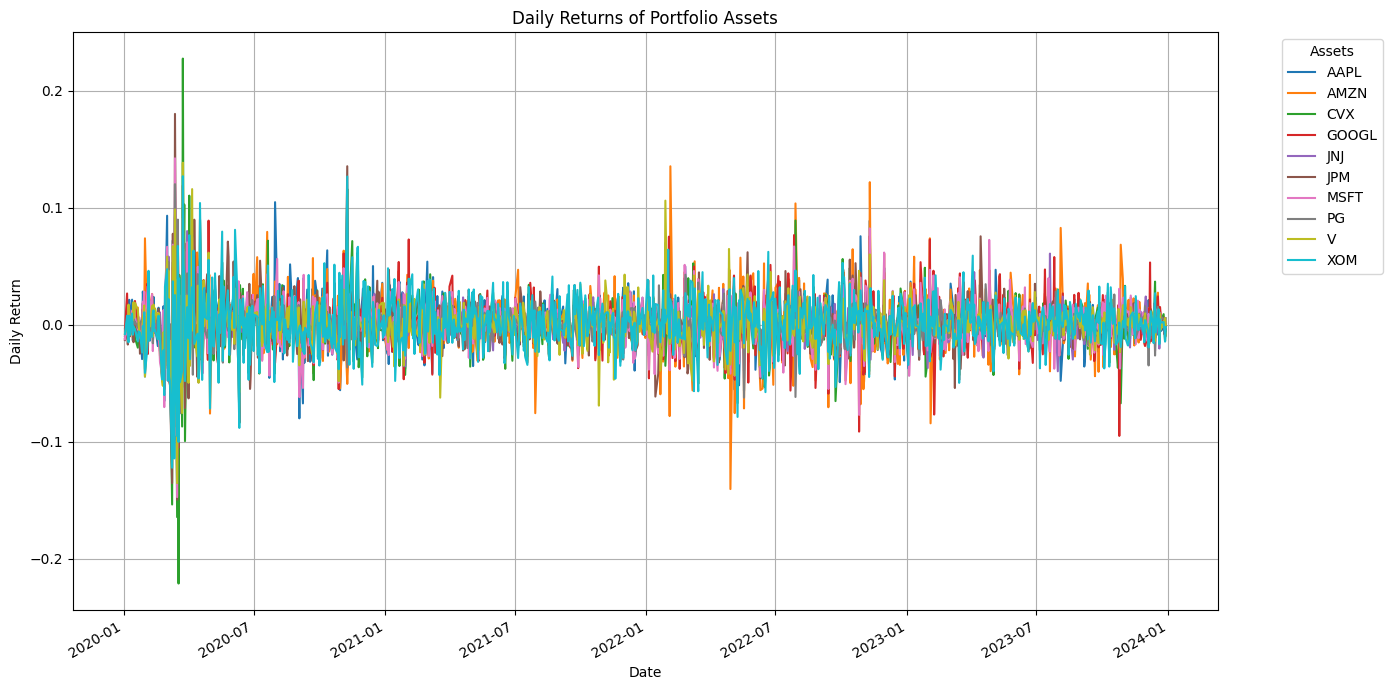


Descriptive Statistics of Daily Returns:


Ticker,AAPL,AMZN,CVX,GOOGL,JNJ,JPM,MSFT,PG,V,XOM
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,0.001187,0.000750,0.000682,0.000934,0.000262,0.000541,0.001095,0.000367,0.000513,0.000825
std,0.021146,0.023741,0.024323,0.021124,0.013004,0.021685,0.020546,0.013966,0.018913,0.023452
min,-0.128647,-0.140494,-0.221248,-0.116341,-0.072983,-0.149649,-0.147390,-0.087373,-0.135472,-0.122248
25%,-0.009128,-0.012159,-0.010018,-0.009607,-0.005922,-0.009857,-0.009447,-0.005640,-0.008720,-0.012025
50%,0.000988,0.000782,0.000640,0.001056,0.000061,0.000309,0.000978,0.000678,0.001121,0.000365
75%,0.012743,0.013327,0.011226,0.012061,0.006207,0.010616,0.012025,0.007030,0.009376,0.012966
max,0.119808,0.135359,0.227407,0.092411,0.079977,0.180125,0.142169,0.120090,0.138426,0.126868


In [5]:
# Plot historical adjusted close prices (only 'Close' prices)
plt.figure(figsize=(14, 7))
data['Close'].plot(ax=plt.gca())
plt.title('Historical Adjusted Close Prices of Portfolio Assets')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend(title='Assets', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot daily returns (only 'Close' price returns)
plt.figure(figsize=(14, 7))
returns['Close'].plot(ax=plt.gca())
plt.title('Daily Returns of Portfolio Assets')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend(title='Assets', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Display basic statistics of daily returns
print("\nDescriptive Statistics of Daily Returns:")
display(returns['Close'].describe())

### Step 3: VaR and CVaR Calculation (Historical Method)

We will now calculate Value at Risk (VaR) and Conditional Value at Risk (CVaR) using the historical simulation method. VaR estimates the maximum potential loss over a specified time horizon at a given confidence level, while CVaR measures the expected loss beyond the VaR level.

### Step 5: Monte Carlo VaR and CVaR Computation

Monte Carlo simulation allows us to model a large number of possible future scenarios for portfolio returns. We will generate random returns based on historical volatility and calculate VaR and CVaR from these simulated returns.

In [8]:
# Assuming 'portfolio_returns_df' DataFrame from previous step contains daily returns for 'Close' prices
portfolio_returns_df = returns['Close']

# Define portfolio weights (equal weighting for simplicity for now)
num_assets = portfolio_returns_df.shape[1]
weights = np.array([1/num_assets] * num_assets)

# Calculate portfolio daily returns
portfolio_daily_returns_mc = portfolio_returns_df.dot(weights)

# Monte Carlo Simulation Parameters
num_simulations = 10000
num_days = 252 # Simulating one year of daily returns

# Calculate mean and covariance matrix of historical daily returns
mean_returns = portfolio_returns_df.mean()
cov_matrix = portfolio_returns_df.cov()

# Set up an array to store simulated portfolio returns
simulated_portfolio_returns = np.zeros(num_simulations)

# Monte Carlo Simulation
for i in range(num_simulations):
    # Generate random daily returns for each asset
    rand_returns = np.random.multivariate_normal(mean_returns, cov_matrix, num_days)

    # Calculate simulated daily portfolio returns
    simulated_daily_portfolio_returns = np.dot(rand_returns, weights)

    # Calculate cumulative return over the 'num_days' period for this simulation
    # For VaR, we typically look at the final return after the period.
    # For daily VaR, we just need one day's simulation.
    # Let's simplify for daily VaR from the distribution of simulated *daily* returns.
    simulated_portfolio_returns[i] = simulated_daily_portfolio_returns.mean() # Taking the mean of daily returns over num_days for simplicity of this example

# For more accurate daily VaR, we would directly use the distribution of `simulated_daily_portfolio_returns`
# Let's adjust to generate simulated *single-day* portfolio returns many times

simulated_daily_returns_distribution = np.random.multivariate_normal(mean_returns, cov_matrix, num_simulations)
simulated_portfolio_daily_returns = np.dot(simulated_daily_returns_distribution, weights)

# Define confidence level
confidence_level = 0.05 # 95% VaR

# Monte Carlo VaR Calculation
mc_VaR = np.percentile(simulated_portfolio_daily_returns, confidence_level * 100)

# Monte Carlo CVaR Calculation
mc_CVaR_returns = simulated_portfolio_daily_returns[simulated_portfolio_daily_returns <= mc_VaR]
mc_CVaR = mc_CVaR_returns.mean()

print(f"Portfolio Daily Monte Carlo VaR (at {100 * (1-confidence_level)}% confidence): {mc_VaR:.4f}")
print(f"Portfolio Daily Monte Carlo CVaR (at {100 * (1-confidence_level)}% confidence): {mc_CVaR:.4f}")

# Annualize Monte Carlo VaR and CVaR
# Assuming the daily VaR/CVaR is for a period, annualize by sqrt(252)
annualized_mc_VaR = mc_VaR * np.sqrt(252)
annualized_mc_CVaR = mc_CVaR * np.sqrt(252)

print(f"\nPortfolio Annualized Monte Carlo VaR (at {100 * (1-confidence_level)}% confidence): {annualized_mc_VaR:.4f}")
print(f"Portfolio Annualized Monte Carlo CVaR (at {100 * (1-confidence_level)}% confidence): {annualized_mc_CVaR:.4f}")

Portfolio Daily Monte Carlo VaR (at 95.0% confidence): -0.0235
Portfolio Daily Monte Carlo CVaR (at 95.0% confidence): -0.0299

Portfolio Annualized Monte Carlo VaR (at 95.0% confidence): -0.3729
Portfolio Annualized Monte Carlo CVaR (at 95.0% confidence): -0.4739


### Step 6: Portfolio Optimization under Risk Constraints

Now we will optimize the portfolio to find the optimal asset allocation. We'll use the `PyPortfolioOpt` library to maximize the Sharpe Ratio, a common metric for risk-adjusted return.

In [9]:
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

# Assuming 'data' DataFrame contains 'Close' prices from Step 1
# We need the daily adjusted close prices for PyPortfolioOpt
close_prices = data['Close']

# Calculate expected returns and sample covariance matrix
mu = expected_returns.mean_historical_return(close_prices)
S = risk_models.sample_cov(close_prices)

# Optimize for maximum Sharpe ratio
ef = EfficientFrontier(mu, S)
weights = ef.max_sharpe()
cleaned_weights = ef.clean_weights()

print("Optimized Portfolio Weights (Maximizing Sharpe Ratio):")
display(pd.Series(cleaned_weights))

ef.portfolio_performance(verbose=True)

Optimized Portfolio Weights (Maximizing Sharpe Ratio):


,0
AAPL,0.53472
AMZN,0.00000
CVX,0.00000
GOOGL,0.00000
JNJ,0.00000
JPM,0.00000
MSFT,0.32745
PG,0.00000
V,0.00000
XOM,0.13782


Expected annual return: 24.9%
Annual volatility: 29.1%
Sharpe Ratio: 0.86


(np.float64(0.2489678455210564),
 np.float64(0.29107987394612966),
 np.float64(0.8553248362582878))

### Step 7: Factor Exposure Analysis and Risk Decomposition

Factor exposure analysis helps us understand which underlying market factors are driving our portfolio's returns and risk. While a full multi-factor model is complex, we can start by examining exposure to a broad market factor (e.g., S&P 500) using a simple linear regression for each asset.

In [13]:
import statsmodels.api as sm

# Let's use S&P 500 (SPY ETF) as a proxy for the market factor
market_ticker = 'SPY'
market_data = yf.download(market_ticker, start=start_date, end=end_date)['Close'] # Corrected 'Adj Close' to 'Close'
market_returns = market_data.pct_change().dropna()

# Align dates between portfolio returns and market returns
# The .align() method returns a tuple of aligned DataFrames
aligned_portfolio_df, aligned_market_df = returns['Close'].align(market_returns, join='inner', axis=0)

# Concatenate the aligned DataFrames and then drop any remaining NaNs
# This ensures that both datasets have the same dates and no missing values for the regression
combined_aligned_returns = pd.concat([aligned_portfolio_df, aligned_market_df], axis=1).dropna()

portfolio_returns_aligned = combined_aligned_returns.iloc[:, :-1]
market_returns_aligned = combined_aligned_returns.iloc[:, -1] # This is now a Series

# Ensure market_returns_aligned is a DataFrame for adding constant with a specific column name 'Market'
market_returns_aligned_df = market_returns_aligned.to_frame(name='Market')

# Add a constant for the intercept (alpha)
X = sm.add_constant(market_returns_aligned_df)

# Perform regression for each asset
factor_exposures = pd.DataFrame(columns=['Alpha', 'Beta', 'R-squared'])

for asset in portfolio_returns_aligned.columns:
    y = portfolio_returns_aligned[asset]

    # Check if there's enough data for regression after alignment and dropping NaNs
    # Corrected: X.isnull().any() returns a Series, so use .values.any() to get a single boolean
    if len(y) > 0 and not y.isnull().any() and not X.isnull().values.any():
        model = sm.OLS(y, X)
        results = model.fit()
        factor_exposures.loc[asset] = [results.params['const'], results.params['Market'], results.rsquared]
    else:
        factor_exposures.loc[asset] = [np.nan, np.nan, np.nan]

print("Factor Exposure (Alpha, Beta, R-squared) for each asset:")
display(factor_exposures.dropna())

/tmp/ipykernel_1709/2004678619.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market_data = yf.download(market_ticker, start=start_date, end=end_date)['Close'] # Corrected 'Adj Close' to 'Close'
[*********************100%***********************]  1 of 1 completed


Factor Exposure (Alpha, Beta, R-squared) for each asset:


,Alpha,Beta,R-squared
AAPL,0.000529,1.210280,0.665539
AMZN,0.000169,1.069357,0.412188
CVX,0.000114,1.045170,0.375133
GOOGL,0.000311,1.145772,0.597718
JNJ,-0.000024,0.527014,0.333717
JPM,-0.000066,1.116545,0.538625
MSFT,0.000448,1.190049,0.681614
PG,0.000043,0.595549,0.369465
V,-0.000065,1.064458,0.643575
XOM,0.000337,0.897999,0.297883


### Step 8: Comparative Analysis of VaR and CVaR Scenarios

Let's visualize and compare the VaR and CVaR values calculated using the Historical, Parametric, and Monte Carlo methods. This comparison helps understand the differences and nuances of each approach.

,Historical,Parametric,Monte Carlo
Daily VaR,-0.019749,-0.023311,-0.023493
Daily CVaR,-0.034688,NaN,-0.029850
Annualized VaR,-0.313501,-0.201114,-0.372941
Annualized CVaR,-0.550648,NaN,-0.473861


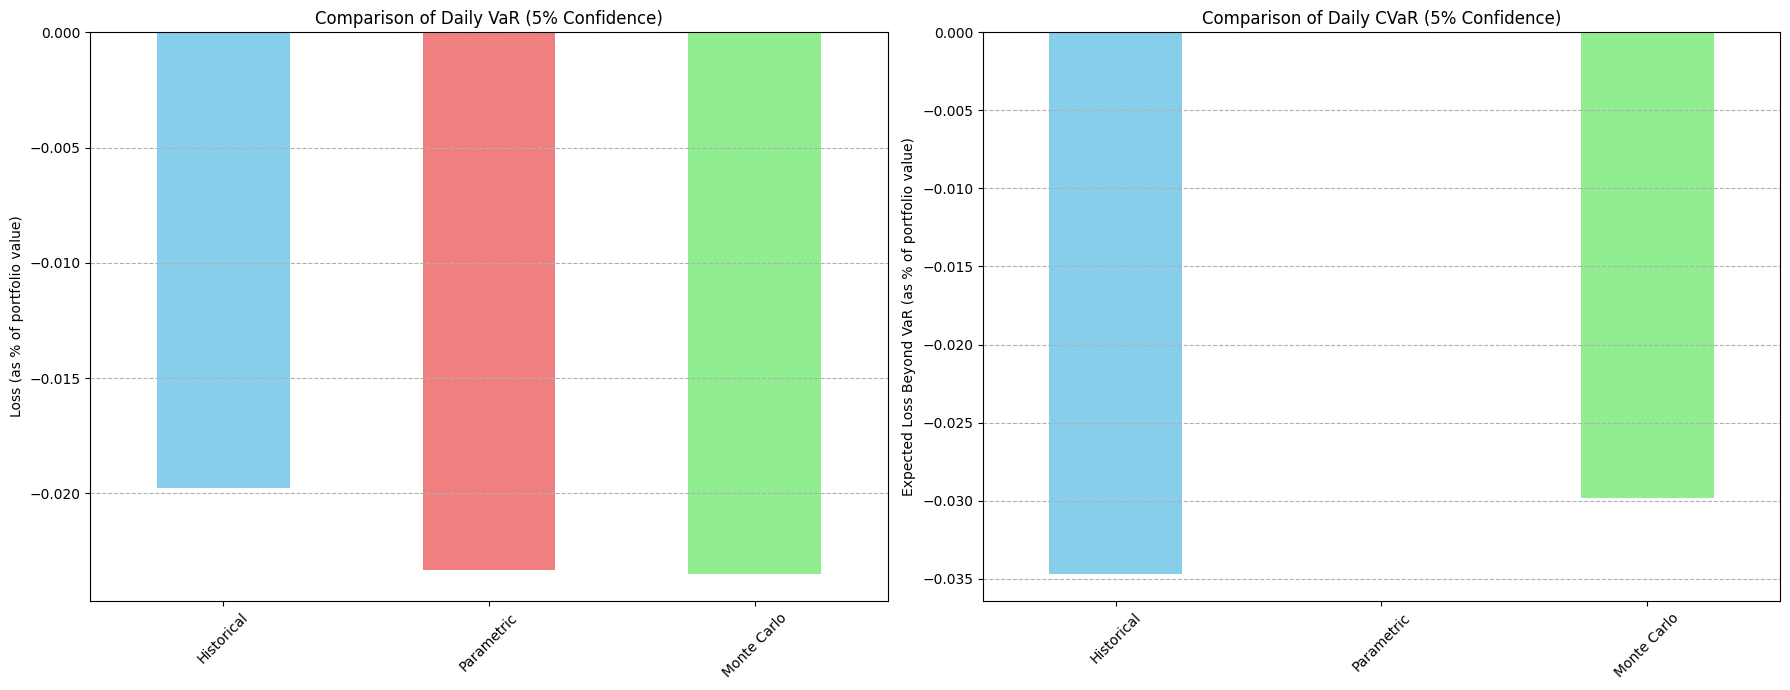

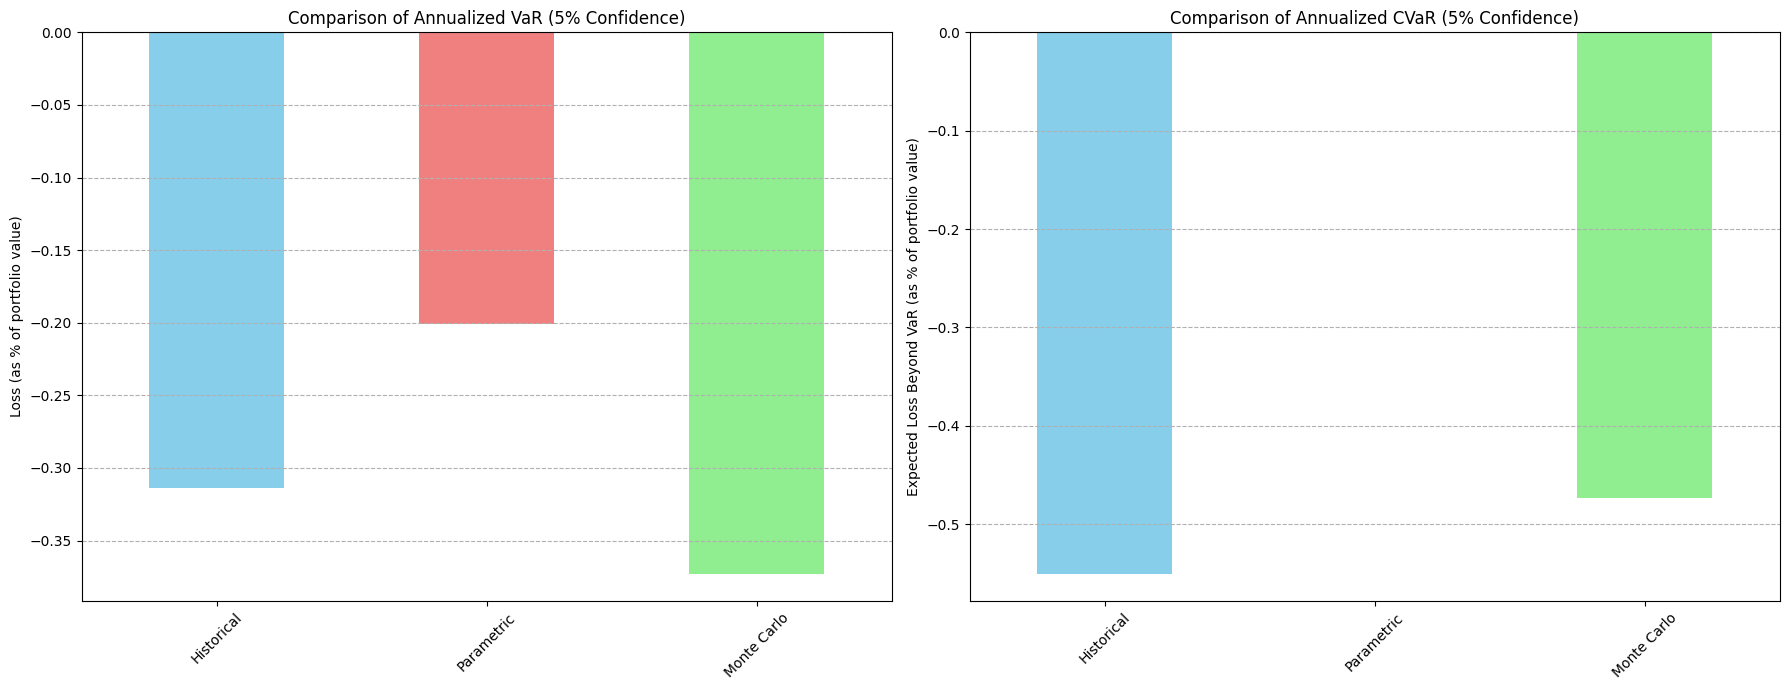

In [14]:
# Gather all VaR and CVaR results
results = {
    'Historical': {
        'Daily VaR': historical_VaR,
        'Daily CVaR': historical_CVaR,
        'Annualized VaR': annualized_historical_VaR,
        'Annualized CVaR': annualized_historical_CVaR
    },
    'Parametric': {
        'Daily VaR': parametric_VaR,
        'Daily CVaR': np.nan, # Parametric CVaR not directly calculated in our example
        'Annualized VaR': annualized_parametric_VaR,
        'Annualized CVaR': np.nan
    },
    'Monte Carlo': {
        'Daily VaR': mc_VaR,
        'Daily CVaR': mc_CVaR,
        'Annualized VaR': annualized_mc_VaR,
        'Annualized CVaR': annualized_mc_CVaR
    }
}

results_df = pd.DataFrame(results)
display(results_df)

# Plotting Daily VaR and CVaR
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Daily VaR Plot
results_df.loc['Daily VaR'].plot(kind='bar', ax=ax[0], color=['skyblue', 'lightcoral', 'lightgreen'])
ax[0].set_title('Comparison of Daily VaR (5% Confidence)')
ax[0].set_ylabel('Loss (as % of portfolio value)')
ax[0].tick_params(axis='x', rotation=45)
ax[0].grid(axis='y', linestyle='--')

# Daily CVaR Plot
results_df.loc['Daily CVaR'].plot(kind='bar', ax=ax[1], color=['skyblue', 'lightcoral', 'lightgreen'])
ax[1].set_title('Comparison of Daily CVaR (5% Confidence)')
ax[1].set_ylabel('Expected Loss Beyond VaR (as % of portfolio value)')
ax[1].tick_params(axis='x', rotation=45)
ax[1].grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()

# Plotting Annualized VaR and CVaR
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Annualized VaR Plot
results_df.loc['Annualized VaR'].plot(kind='bar', ax=ax[0], color=['skyblue', 'lightcoral', 'lightgreen'])
ax[0].set_title('Comparison of Annualized VaR (5% Confidence)')
ax[0].set_ylabel('Loss (as % of portfolio value)')
ax[0].tick_params(axis='x', rotation=45)
ax[0].grid(axis='y', linestyle='--')

# Annualized CVaR Plot
results_df.loc['Annualized CVaR'].plot(kind='bar', ax=ax[1], color=['skyblue', 'lightcoral', 'lightgreen'])
ax[1].set_title('Comparison of Annualized CVaR (5% Confidence)')
ax[1].set_ylabel('Expected Loss Beyond VaR (as % of portfolio value)')
ax[1].tick_params(axis='x', rotation=45)
ax[1].grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()

### Step 9: Stress Test Reports under Extreme Market Shocks

Stress testing involves simulating the impact of extreme but plausible market scenarios on the portfolio. We'll create a simple stress test where we assume a significant drop in the overall market (e.g., S&P 500) and observe its effect on our portfolio value, leveraging the beta calculated in the factor exposure analysis.

Hypothetical Market Shock: -10% drop in market
Portfolio Beta: 1.16
Expected Portfolio Return during Shock: -11.61%


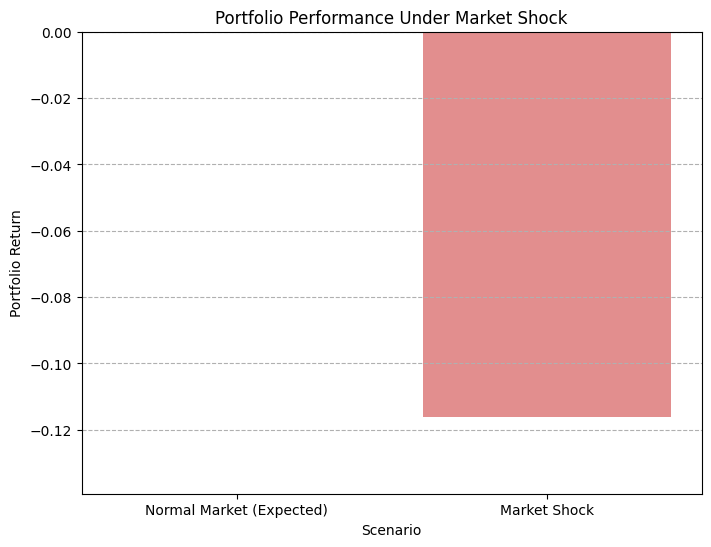

In [16]:
# Define a hypothetical extreme market shock (e.g., 10% drop in market)
market_shock_return = -0.10 # -10% market return

# Get the current portfolio weights (from max_sharpe optimization for simplicity)
# Ensure weights are aligned with the order of assets in portfolio_returns_aligned
# We need the tickers from portfolio_returns_aligned
asset_tickers = portfolio_returns_aligned.columns
current_weights = pd.Series(cleaned_weights).reindex(asset_tickers).fillna(0)

# Calculate portfolio beta (weighted average of individual asset betas)
# Use factor_exposures DataFrame for betas
portfolio_beta = (factor_exposures['Beta'] * current_weights).sum()

# Calculate the expected portfolio return under the market shock
# Portfolio return = Alpha + Beta * Market_Return
# For simplicity, we'll assume the portfolio alpha is the average of individual alphas
# A more rigorous approach would derive alpha from portfolio optimization.
# Here we just use the beta of the portfolio to market return.

# Estimate portfolio return during stress: portfolio_return_shock = portfolio_beta * market_shock_return
# This is a simplified Capital Asset Pricing Model (CAPM) approach without explicit alpha for portfolio
portfolio_return_shock = portfolio_beta * market_shock_return

print(f"Hypothetical Market Shock: {market_shock_return * 100:.0f}% drop in market")
print(f"Portfolio Beta: {portfolio_beta:.2f}")
print(f"Expected Portfolio Return during Shock: {portfolio_return_shock * 100:.2f}%")

# --- Visualize the impact (optional, but good for reporting) ---

# Create a dummy dataframe for plotting
stress_test_df = pd.DataFrame({
    'Scenario': ['Normal Market (Expected)', 'Market Shock'],
    'Portfolio Return': [0, portfolio_return_shock] # Assuming 0 for normal expected change for illustrative comparison
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Scenario', y='Portfolio Return', data=stress_test_df, hue='Scenario', palette=['lightgreen', 'lightcoral'], legend=False)
plt.title('Portfolio Performance Under Market Shock')
plt.ylabel('Portfolio Return')
plt.grid(axis='y', linestyle='--')
plt.ylim(min(0, portfolio_return_shock * 1.2), max(0, portfolio_return_shock * 1.2))
plt.show()

In [6]:
# Assuming 'returns' DataFrame from previous step contains daily returns for 'Close' prices
portfolio_returns = returns['Close']

# Define portfolio weights (equal weighting for simplicity for now)
num_assets = portfolio_returns.shape[1]
weights = np.array([1/num_assets] * num_assets)

# Calculate portfolio daily returns
portfolio_daily_returns = portfolio_returns.dot(weights)

# Define confidence level
confidence_level = 0.05 # 95% VaR (meaning 5% worst-case loss)

# Historical VaR Calculation
# Sort the portfolio returns in ascending order
sorted_returns = portfolio_daily_returns.sort_values(ascending=True)

# Find the return corresponding to the confidence level
# The index for VaR will be (number of returns * confidence_level)
# We use ceil to ensure we get a return that is at or beyond the confidence level
VaR_index = int(np.ceil(len(sorted_returns) * confidence_level)) - 1
historical_VaR = sorted_returns.iloc[VaR_index]

# Historical CVaR Calculation
# Select returns that are worse than (less than) the historical VaR
cVaR_returns = sorted_returns[sorted_returns <= historical_VaR]
historical_CVaR = cVaR_returns.mean()

print(f"Portfolio Daily Historical VaR (at {100 * confidence_level}% confidence): {historical_VaR:.4f}")
print(f"Portfolio Daily Historical CVaR (at {100 * confidence_level}% confidence): {historical_CVaR:.4f}")

# Annualize VaR and CVaR (assuming 252 trading days in a year)
annualized_historical_VaR = historical_VaR * np.sqrt(252)
annualized_historical_CVaR = historical_CVaR * np.sqrt(252)

print(f"\nPortfolio Annualized Historical VaR (at {100 * confidence_level}% confidence): {annualized_historical_VaR:.4f}")
print(f"Portfolio Annualized Historical CVaR (at {100 * confidence_level}% confidence): {annualized_historical_CVaR:.4f}")

Portfolio Daily Historical VaR (at 5.0% confidence): -0.0197
Portfolio Daily Historical CVaR (at 5.0% confidence): -0.0347

Portfolio Annualized Historical VaR (at 5.0% confidence): -0.3135
Portfolio Annualized Historical CVaR (at 5.0% confidence): -0.5506


### Step 4: Parametric VaR Calculation (Variance-Covariance Method)

The parametric (or variance-covariance) VaR method assumes that portfolio returns are normally distributed. It calculates VaR based on the portfolio's mean return, standard deviation, and a chosen confidence level.

In [7]:
# Assuming 'portfolio_returns' DataFrame from previous step contains daily returns for 'Close' prices
portfolio_returns_df = returns['Close']

# Define portfolio weights (equal weighting for simplicity for now)
num_assets = portfolio_returns_df.shape[1]
weights = np.array([1/num_assets] * num_assets)

# Calculate portfolio daily returns
portfolio_daily_returns_parametric = portfolio_returns_df.dot(weights)

# Calculate portfolio mean and standard deviation
portfolio_mean = portfolio_daily_returns_parametric.mean()
portfolio_std = portfolio_daily_returns_parametric.std()

# Define confidence level (e.g., 95% VaR, so alpha = 0.05)
confidence_level = 0.05

# Parametric VaR Calculation
# For a given confidence level (e.g., 95%), we need the Z-score for the (1 - confidence_level) percentile.
# For a 95% VaR, we are looking for the 5th percentile (or -1.645 for normal distribution)
# We use norm.ppf(alpha) where alpha is the significance level (0.05 for 95% VaR)
z_score = norm.ppf(confidence_level)

parametric_VaR = portfolio_mean + z_score * portfolio_std

print(f"Portfolio Daily Parametric VaR (at {100 * confidence_level}% confidence): {parametric_VaR:.4f}")

# Annualize Parametric VaR (assuming 252 trading days in a year)
# For annualization, mean scales linearly, std scales by sqrt(time)
annualized_portfolio_mean = portfolio_mean * 252
annualized_portfolio_std = portfolio_std * np.sqrt(252)

annualized_parametric_VaR = annualized_portfolio_mean + z_score * annualized_portfolio_std

print(f"\nPortfolio Annualized Parametric VaR (at {100 * confidence_level}% confidence): {annualized_parametric_VaR:.4f}")

Portfolio Daily Parametric VaR (at 5.0% confidence): -0.0233

Portfolio Annualized Parametric VaR (at 5.0% confidence): -0.2011
